# Multi-Objective Bayesian Optimization for Drug Discovery
## Complete Pipeline: Data Cleaning → GP Modeling → Pareto Optimization

**Objectives:**
1. **Primary**: Maximize predicted potency (pIC50)
2. **Secondary**: Minimize testing cost/complexity (molecular weight, synthetic accessibility)

**Pipeline Overview:**
1. Data Loading & Cleaning
2. Molecular Descriptor Generation
3. Multi-Objective Gaussian Process Modeling
4. Pareto Front Optimization
5. Strategy Comparison & Visualization
6. Results Export

---
## 1. Imports and Configuration

In [43]:
# Core imports
import pandas as pd
import numpy as np
import torch
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# BoTorch & GPyTorch
import botorch
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.utils.multi_objective.pareto import is_non_dominated
from gpytorch.mlls import ExactMarginalLogLikelihood

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# RDKit
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set style and seeds
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
np.random.seed(42)
torch.manual_seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"BoTorch version: {botorch.__version__}")
print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

PyTorch version: 2.7.1
BoTorch version: 0.9.2
Device: cpu


In [44]:
CONFIG = {
    # Input/Output paths
    'raw_data_path': '/Users/amitchaudhary/Downloads/archive-4/AChE_Bioactivity_data_1.csv',  # Set if cleaning raw data
    'output_dir': 'results',
    
    # Feature columns for GP models
    'feature_cols': ['mol_weight', 'logp', 'hbd', 'hba', 'rotatable_bonds', 'tpsa', 'sa_score', 'rings'],
    
    # Data split parameters
    'test_size': 0.3,
    'random_state': 42,
    
    # Selection parameters
    'n_compounds_to_select': 20,
    
    # Cost metric weights
    'mw_weight': 0.5,
    'sa_weight': 0.5,
}

# Create output directory
Path(CONFIG['output_dir']).mkdir(parents=True, exist_ok=True)
print("Configuration loaded successfully!")

Configuration loaded successfully!


---
## 2. Data Cleaning Functions

In [45]:
def safe_mol_from_smiles(smiles):
    """Safely convert SMILES to RDKit molecule."""
    if pd.isna(smiles):
        return None
    try:
        mol = Chem.MolFromSmiles(str(smiles))
        if mol is not None:
            Chem.SanitizeMol(mol)
        return mol
    except:
        return None


def calculate_descriptors(mol):
    """Calculate molecular descriptors for a molecule."""
    if mol is None:
        return {}
    try:
        return {
            'mol_weight': Descriptors.MolWt(mol),
            'logp': Descriptors.MolLogP(mol),
            'hbd': Descriptors.NumHDonors(mol),
            'hba': Descriptors.NumHAcceptors(mol),
            'rotatable_bonds': Descriptors.NumRotatableBonds(mol),
            'heavy_atoms': Descriptors.HeavyAtomCount(mol),
            'rings': Descriptors.RingCount(mol),
            'tpsa': Descriptors.TPSA(mol),
            'aromatic_rings': Descriptors.NumAromaticRings(mol),
            'amide_bonds': Descriptors.NumAmideBonds(mol),
            'num_heteroatoms': Descriptors.NumHeteroatoms(mol),
            'num_aromatic_heterocycles': Descriptors.NumAromaticHeterocycles(mol),
            'num_aliphatic_heterocycles': Descriptors.NumAliphaticHeterocycles(mol),
        }
    except:
        return {}


def calculate_sa_score(mol):
    """Calculate synthetic accessibility score (heuristic: 1=easy, 10=hard)."""
    if mol is None:
        return 10.0
    try:
        mw = Descriptors.MolWt(mol)
        rings = Descriptors.RingCount(mol)
        try:
            chiral_centers = len(Chem.FindMolChiralCenters(mol, includeUnassigned=True))
        except:
            chiral_centers = 0
        try:
            ring_info = mol.GetRingInfo()
            complex_rings = sum(1 for ring in ring_info.AtomRings() if len(ring) > 6)
        except:
            complex_rings = 0
        
        sa_score = mw/500 * 2 + rings * 0.5 + chiral_centers * 1.5 + complex_rings * 2
        return min(10, max(1, sa_score))
    except:
        return 10.0


def generate_molecular_descriptors(df):
    """Generate all molecular descriptors for a DataFrame."""
    print("   Converting SMILES to molecules...")
    df['molecule'] = df['canonical_smiles'].apply(safe_mol_from_smiles)
    
    # Remove failed conversions
    initial_count = len(df)
    df = df[df['molecule'].notna()].copy()
    print(f"   Valid molecules: {len(df)}/{initial_count}")
    
    # Calculate descriptors
    print("   Calculating molecular descriptors...")
    descriptors_list = []
    for idx, mol in enumerate(df['molecule']):
        if idx % 1000 == 0 and idx > 0:
            print(f"      Processed {idx}/{len(df)} molecules...")
        descriptors_list.append(calculate_descriptors(mol))
    
    descriptors_df = pd.DataFrame(descriptors_list)
    df = pd.concat([df.reset_index(drop=True), descriptors_df], axis=1)
    
    # Calculate SA score
    print("   Calculating synthetic accessibility scores...")
    df['sa_score'] = df['molecule'].apply(calculate_sa_score)
    
    # Drop molecule column
    df = df.drop(columns=['molecule'])
    
    print(f"   Generated {len(descriptors_df.columns)} descriptors + SA score")
    return df

In [46]:
def clean_chembl_dataset(df):

    original_size = len(df)
    df_clean = df.copy()
    
    print("DATA CLEANING PIPELINE")
    
    # Step 1: Remove empty columns
    empty_cols = df_clean.columns[df_clean.isna().all()].tolist()
    if empty_cols:
        print(f"\n1. Removing {len(empty_cols)} empty columns: {empty_cols}")
        df_clean = df_clean.drop(columns=empty_cols)
    
    # Step 2: Filter for IC50 data
    print("\n2. Filtering for IC50 measurements...")
    if 'standard_type' in df_clean.columns:
        ic50_before = len(df_clean)
        df_clean = df_clean[df_clean['standard_type'] == 'IC50']
        print(f"   Kept {len(df_clean)}/{ic50_before} IC50 measurements")
    
    # Step 3: Remove missing critical data
    print("\n3. Removing rows with missing critical data...")
    df_clean = df_clean[df_clean['standard_value'].notna()]
    print(f"   - After removing missing standard_value: {len(df_clean)}")
    df_clean = df_clean[df_clean['canonical_smiles'].notna()]
    print(f"   - After removing missing SMILES: {len(df_clean)}")
    
    # Step 4: Apply validity filters
    print("\n4. Applying data quality filters...")
    if 'data_validity_comment' in df_clean.columns:
        valid_before = len(df_clean)
        df_clean = df_clean[df_clean['data_validity_comment'].isna()]
        print(f"   - After validity filter: {len(df_clean)}/{valid_before}")
    
    if 'standard_relation' in df_clean.columns:
        relation_before = len(df_clean)
        df_clean = df_clean[df_clean['standard_relation'] == '=']
        print(f"   - After exact measurements filter: {len(df_clean)}/{relation_before}")
    
    # Step 5: Unit consistency
    print("\n5. Validating units and values...")
    if 'standard_units' in df_clean.columns:
        unit_counts = df_clean['standard_units'].value_counts()
        print(f"   Unit distribution: {unit_counts.to_dict()}")
        unit_before = len(df_clean)
        df_clean = df_clean[df_clean['standard_units'] == 'nM']
        print(f"   - After nM unit filter: {len(df_clean)}/{unit_before}")
    
    value_before = len(df_clean)
    df_clean = df_clean[df_clean['standard_value'] > 0]
    print(f"   - After positive value filter: {len(df_clean)}/{value_before}")
    
    # Step 6: Handle duplicates
    print("\n6. Handling duplicate compounds...")
    duplicate_count = df_clean['canonical_smiles'].duplicated().sum()
    print(f"   Found {duplicate_count} duplicate SMILES")
    
    if duplicate_count > 0:
        agg_rules = {'standard_value': 'median', 'molecule_chembl_id': 'first'}
        
        if 'assay_chembl_id' in df_clean.columns:
            agg_rules['assay_chembl_id'] = 'count'
        if 'document_chembl_id' in df_clean.columns:
            agg_rules['document_chembl_id'] = 'nunique'
        if 'pchembl_value' in df_clean.columns:
            agg_rules['pchembl_value'] = 'median'
        
        df_clean = df_clean.groupby('canonical_smiles').agg(agg_rules).reset_index()
        
        if 'assay_chembl_id' in df_clean.columns:
            df_clean = df_clean.rename(columns={'assay_chembl_id': 'num_assays'})
        if 'document_chembl_id' in df_clean.columns:
            df_clean = df_clean.rename(columns={'document_chembl_id': 'num_publications'})
    
    print(f"   After deduplication: {len(df_clean)} unique compounds")
    
    # Step 7: Calculate potency metrics
    print("\n7. Calculating potency metrics...")
    df_clean['pIC50'] = -np.log10(df_clean['standard_value'] * 1e-9)
    df_clean['IC50_nM'] = df_clean['standard_value']
    print(f"   pIC50 range: {df_clean['pIC50'].min():.2f} - {df_clean['pIC50'].max():.2f}")
    print(f"   IC50 range: {df_clean['IC50_nM'].min():.2f} - {df_clean['IC50_nM'].max():.2f} nM")
    
    # Step 8: Generate molecular descriptors
    print("\n8. Generating molecular descriptors...")
    df_clean = generate_molecular_descriptors(df_clean)
    
    print("\n" + "="*60)
    print("CLEANING COMPLETE")
    print("="*60)
    print(f"Original dataset: {original_size} rows")
    print(f"Cleaned dataset: {len(df_clean)} rows")
    print(f"Data retention: {len(df_clean)/original_size*100:.1f}%")
    
    return df_clean

---
## 3. Load and Prepare Data

In [47]:
raw_df = pd.read_csv(CONFIG['raw_data_path'])
print(f"Raw dataset shape: {raw_df.shape}")
df = clean_chembl_dataset(raw_df)

# Save cleaned data for future use
df.to_csv(f"{CONFIG['output_dir']}/cleaned_data.csv", index=False)
print(f"\nCleaned data saved to: {CONFIG['output_dir']}/cleaned_data.csv")

Raw dataset shape: (15542, 45)
DATA CLEANING PIPELINE

1. Removing 6 empty columns: ['assay_variant_accession', 'assay_variant_mutation', 'standard_text_value', 'standard_upper_value', 'text_value', 'toid']

2. Filtering for IC50 measurements...
   Kept 8205/15542 IC50 measurements

3. Removing rows with missing critical data...
   - After removing missing standard_value: 6949
   - After removing missing SMILES: 6947

4. Applying data quality filters...
   - After validity filter: 6352/6947
   - After exact measurements filter: 5801/6352

5. Validating units and values...
   Unit distribution: {'nM': 5787, 'ug.mL-1': 14}
   - After nM unit filter: 5787/5801
   - After positive value filter: 5787/5787

6. Handling duplicate compounds...
   Found 1163 duplicate SMILES
   After deduplication: 4624 unique compounds

7. Calculating potency metrics...
   pIC50 range: 4.00 - 10.96
   IC50 range: 0.01 - 100000.00 nM

8. Generating molecular descriptors...
   Converting SMILES to molecules...
 

In [48]:
# Calculate cost metric
df['cost_metric'] = (
    CONFIG['mw_weight'] * df['mol_weight'] / 1000.0 + 
    CONFIG['sa_weight'] * df['sa_score'] / 10.0
)

print("Cost Metric Statistics:")
print(df['cost_metric'].describe())

print("\npIC50 Statistics:")
print(df['pIC50'].describe())

Cost Metric Statistics:
count    4624.000000
mean        0.449343
std         0.148726
min         0.080520
25%         0.345181
50%         0.425039
75%         0.522006
max         1.117731
Name: cost_metric, dtype: float64

pIC50 Statistics:
count    4624.000000
mean        6.179718
std         1.309200
min         4.000000
25%         5.142668
50%         6.004365
75%         7.049976
max        10.960586
Name: pIC50, dtype: float64


---
## 4. Data Visualization

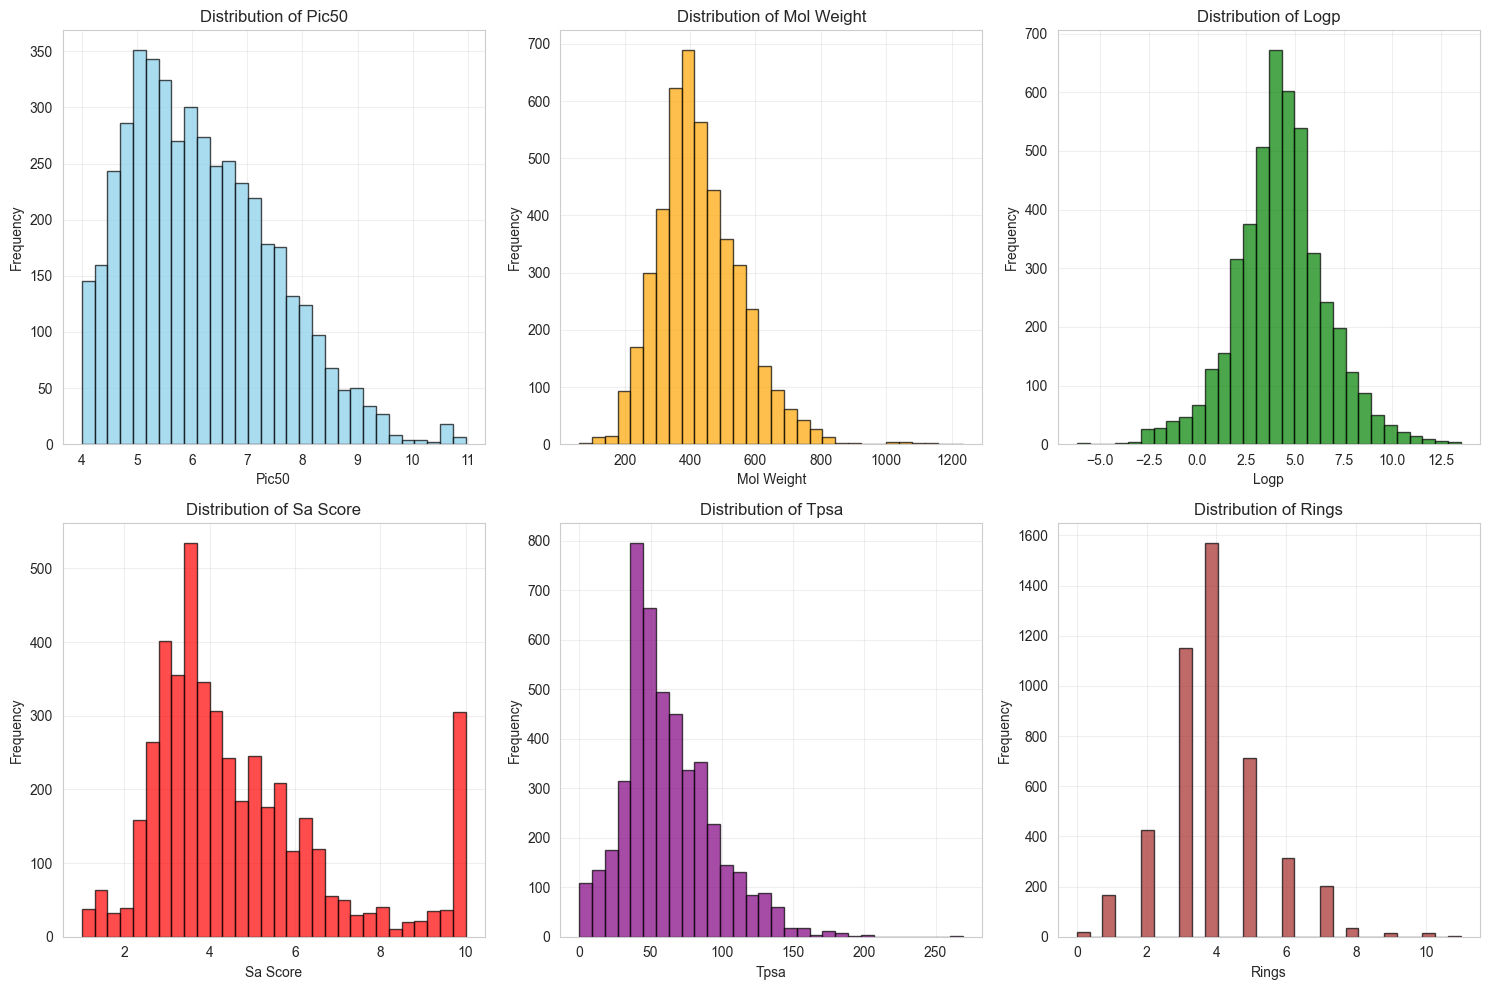

In [49]:
# Distribution plots
cols_to_plot = ['pIC50', 'mol_weight', 'logp', 'sa_score', 'tpsa', 'rings']
available_cols = [c for c in cols_to_plot if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
colors = ['skyblue', 'orange', 'green', 'red', 'purple', 'brown']

for i, col in enumerate(available_cols):
    axes[i].hist(df[col], bins=30, edgecolor='black', alpha=0.7, color=colors[i])
    axes[i].set_xlabel(col.replace('_', ' ').title())
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'Distribution of {col.replace("_", " ").title()}')
    axes[i].grid(True, alpha=0.3)

for i in range(len(available_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/data_distributions.png", dpi=300, bbox_inches='tight')
plt.show()

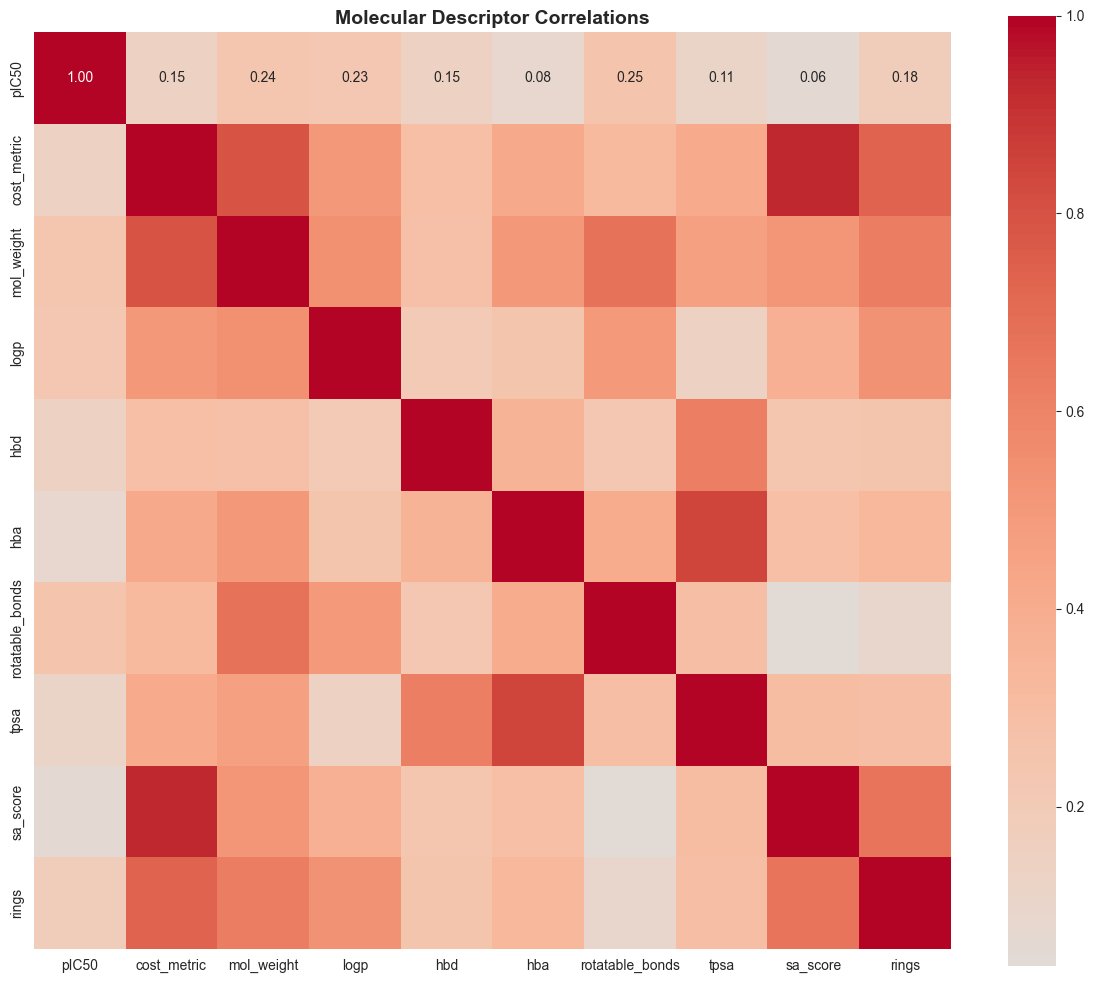

In [50]:
# Correlation heatmap
corr_cols = ['pIC50', 'cost_metric'] + CONFIG['feature_cols']
corr_cols = [c for c in corr_cols if c in df.columns]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, square=True, fmt='.2f')
plt.title('Molecular Descriptor Correlations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

---
## 5. Prepare Data for Gaussian Process Models

In [51]:
# Extract features and objectives
X = df[CONFIG['feature_cols']].values
y_potency = df['pIC50'].values
y_cost = df['cost_metric'].values

# Multi-objective: maximize potency, maximize -cost (minimize cost)
y_objectives = np.column_stack([y_potency, -y_cost])

print(f"Feature matrix shape: {X.shape}")
print(f"Objective matrix shape: {y_objectives.shape}")
print(f"\nObjective 1 (Potency - pIC50) range: [{y_objectives[:, 0].min():.2f}, {y_objectives[:, 0].max():.2f}]")
print(f"Objective 2 (-Cost) range: [{y_objectives[:, 1].min():.2f}, {y_objectives[:, 1].max():.2f}]")

Feature matrix shape: (4624, 8)
Objective matrix shape: (4624, 2)

Objective 1 (Potency - pIC50) range: [4.00, 10.96]
Objective 2 (-Cost) range: [-1.12, -0.08]


In [52]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_objectives, 
    test_size=CONFIG['test_size'], 
    random_state=CONFIG['random_state']
)

df_train, df_test = train_test_split(
    df, 
    test_size=CONFIG['test_size'], 
    random_state=CONFIG['random_state']
)
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print(f"Training set size: {len(X_train)}")
print(f"Test/Candidate set size: {len(X_test)}")

# Standardize features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Convert to PyTorch tensors
X_train_torch = torch.tensor(X_train_scaled, dtype=torch.float64)
y_train_torch = torch.tensor(y_train, dtype=torch.float64)
X_test_torch = torch.tensor(X_test_scaled, dtype=torch.float64)
y_test_torch = torch.tensor(y_test, dtype=torch.float64)

print(f"\nTensor shapes:")
print(f"X_train: {X_train_torch.shape}")
print(f"y_train: {y_train_torch.shape}")
print(f"X_test: {X_test_torch.shape}")

Training set size: 3236
Test/Candidate set size: 1388

Tensor shapes:
X_train: torch.Size([3236, 8])
y_train: torch.Size([3236, 2])
X_test: torch.Size([1388, 8])


---
## 6. Train Gaussian Process Surrogate Models

In [53]:
def train_gp_model(X_train, y_train, objective_name=""):
    """Train a SingleTaskGP model for a given objective."""
    print(f"Training GP for {objective_name}...")
    gp_model = SingleTaskGP(X_train, y_train.unsqueeze(-1))
    mll = ExactMarginalLogLikelihood(gp_model.likelihood, gp_model)
    fit_gpytorch_mll(mll)
    print(f"✓ GP model trained for {objective_name}")
    return gp_model


print("\n" + "="*60)
print("TRAINING GAUSSIAN PROCESS MODELS")
print("="*60 + "\n")

# Train GP for potency
gp_potency = train_gp_model(X_train_torch, y_train_torch[:, 0], "Potency (pIC50)")

# Train GP for negative cost
gp_cost = train_gp_model(X_train_torch, y_train_torch[:, 1], "Negative Cost")

print("\n✓ Both GP models trained successfully!")


TRAINING GAUSSIAN PROCESS MODELS

Training GP for Potency (pIC50)...
✓ GP model trained for Potency (pIC50)
Training GP for Negative Cost...
✓ GP model trained for Negative Cost

✓ Both GP models trained successfully!


---
## 7. Validate GP Models

In [54]:
# Make predictions on test set
with torch.no_grad():
    gp_potency.eval()
    gp_cost.eval()
    
    pred_potency = gp_potency.posterior(X_test_torch).mean.numpy().flatten()
    pred_neg_cost = gp_cost.posterior(X_test_torch).mean.numpy().flatten()

# Calculate metrics
potency_r2 = r2_score(y_test[:, 0], pred_potency)
potency_mse = mean_squared_error(y_test[:, 0], pred_potency)
potency_mae = mean_absolute_error(y_test[:, 0], pred_potency)

cost_r2 = r2_score(y_test[:, 1], pred_neg_cost)
cost_mse = mean_squared_error(y_test[:, 1], pred_neg_cost)
cost_mae = mean_absolute_error(y_test[:, 1], pred_neg_cost)

print("\n" + "="*60)
print("GP MODEL VALIDATION RESULTS")
print("="*60)
print(f"\nPotency (pIC50) Model:")
print(f"  R² Score: {potency_r2:.4f}")
print(f"  MSE: {potency_mse:.4f}")
print(f"  MAE: {potency_mae:.4f}")
print(f"\nNegative Cost Model:")
print(f"  R² Score: {cost_r2:.4f}")
print(f"  MSE: {cost_mse:.4f}")
print(f"  MAE: {cost_mae:.4f}")
print("="*60)


GP MODEL VALIDATION RESULTS

Potency (pIC50) Model:
  R² Score: 0.5263
  MSE: 0.7797
  MAE: 0.6473

Negative Cost Model:
  R² Score: 1.0000
  MSE: 0.0000
  MAE: 0.0004


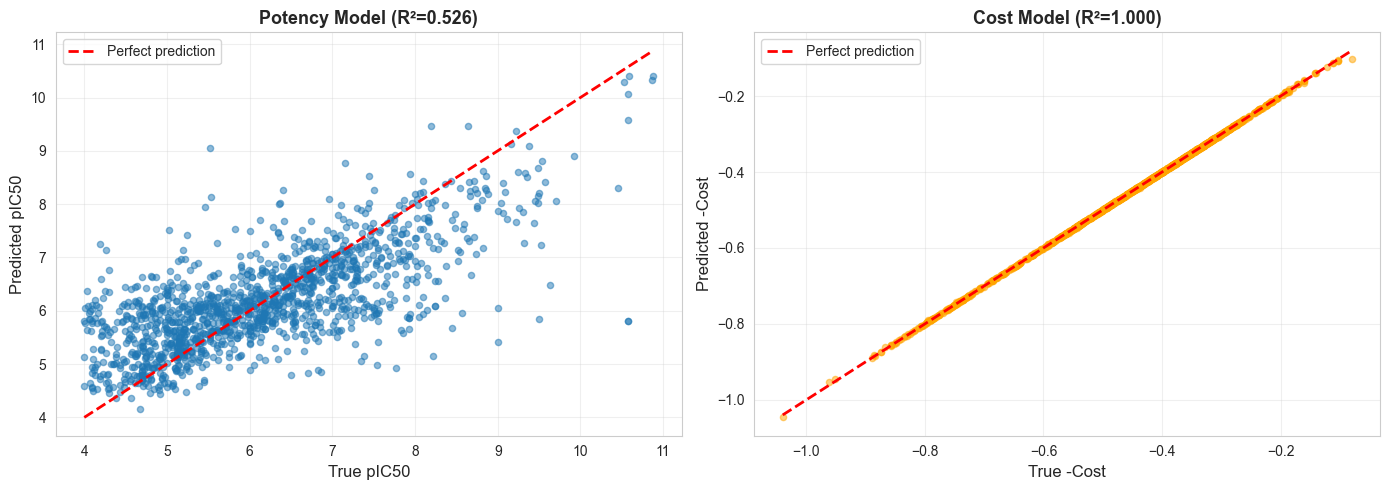

In [55]:
# Visualization of GP predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Potency predictions
axes[0].scatter(y_test[:, 0], pred_potency, alpha=0.5, s=20)
axes[0].plot([y_test[:, 0].min(), y_test[:, 0].max()], 
             [y_test[:, 0].min(), y_test[:, 0].max()], 
             'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('True pIC50', fontsize=12)
axes[0].set_ylabel('Predicted pIC50', fontsize=12)
axes[0].set_title(f'Potency Model (R²={potency_r2:.3f})', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Cost predictions
axes[1].scatter(y_test[:, 1], pred_neg_cost, alpha=0.5, s=20, color='orange')
axes[1].plot([y_test[:, 1].min(), y_test[:, 1].max()], 
             [y_test[:, 1].min(), y_test[:, 1].max()], 
             'r--', lw=2, label='Perfect prediction')
axes[1].set_xlabel('True -Cost', fontsize=12)
axes[1].set_ylabel('Predicted -Cost', fontsize=12)
axes[1].set_title(f'Cost Model (R²={cost_r2:.3f})', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/gp_validation.png", dpi=300, bbox_inches='tight')
plt.show()

---
## 8. Compute Pareto Front

In [56]:
# Get predictions and uncertainties for all candidates
with torch.no_grad():
    gp_potency.eval()
    gp_cost.eval()
    
    posterior_potency = gp_potency.posterior(X_test_torch)
    posterior_cost = gp_cost.posterior(X_test_torch)
    
    mean_potency = posterior_potency.mean.squeeze(-1)
    std_potency = posterior_potency.variance.sqrt().squeeze(-1)
    mean_cost = posterior_cost.mean.squeeze(-1)
    std_cost = posterior_cost.variance.sqrt().squeeze(-1)

# Combine predictions
predicted_objectives = torch.stack([mean_potency, mean_cost], dim=-1)

print(f"Predicted objectives shape: {predicted_objectives.shape}")
print(f"\nPredicted Potency range: [{mean_potency.min():.2f}, {mean_potency.max():.2f}]")
print(f"Predicted -Cost range: [{mean_cost.min():.2f}, {mean_cost.max():.2f}]")

Predicted objectives shape: torch.Size([1388, 2])

Predicted Potency range: [4.16, 10.41]
Predicted -Cost range: [-1.05, -0.10]


In [57]:
# Compute Pareto front from predictions
pareto_mask = is_non_dominated(predicted_objectives)
pareto_indices = torch.where(pareto_mask)[0]

print(f"\nNumber of Pareto-optimal compounds: {len(pareto_indices)} out of {len(X_test)}")
print(f"Percentage on Pareto front: {100*len(pareto_indices)/len(X_test):.1f}%")

# Get Pareto compounds
pareto_compounds = df_test.iloc[pareto_indices.numpy()].copy()
pareto_compounds['predicted_potency'] = mean_potency[pareto_indices].numpy()
pareto_compounds['predicted_neg_cost'] = mean_cost[pareto_indices].numpy()

print(f"\nTop 5 Pareto-optimal compounds by potency:")
display(pareto_compounds.nlargest(5, 'predicted_potency')[['canonical_smiles', 'pIC50', 'cost_metric', 'predicted_potency']])


Number of Pareto-optimal compounds: 8 out of 1388
Percentage on Pareto front: 0.6%

Top 5 Pareto-optimal compounds by potency:


,canonical_smiles,pIC50,cost_metric,predicted_potency
675,COc1ccccc1C(=O)Nc1ccc2c(c1)CN(C(=O)c1cccc(C)c1...,10.586365,0.390123,10.412435
1326,O=C(Nc1ccc2c(c1)CN(C(=O)c1ccccc1)C(=O)C2)c1ccc...,10.878440,0.383397,10.399823
598,Cc1cccc(C(=O)Nc2ccc3c(c2)CN(C(=O)c2cccc(C)c2)C...,10.869023,0.378923,10.327219
804,CC1CCN(CCc2ccccc2)CC1,6.744727,0.192330,7.674515
856,CC(C)(C)c1cccc(C(=O)C(F)(F)F)c1,8.008774,0.186160,7.368923


---
## 9. Baseline Strategies & Comparison

In [58]:
def get_baseline_strategies(df_candidates, n_select=20):
    strategies = {}
    
    # Random selection
    strategies['Random'] = df_candidates.sample(n=min(n_select, len(df_candidates)), random_state=42)
    
    # Top potency only
    strategies['Top Potency'] = df_candidates.nlargest(n_select, 'pIC50')
    
    # Lowest cost only
    strategies['Lowest Cost'] = df_candidates.nsmallest(n_select, 'cost_metric')
    
    # Balanced (highest potency-to-cost ratio)
    df_copy = df_candidates.copy()
    df_copy['potency_cost_ratio'] = df_copy['pIC50'] / (df_copy['cost_metric'] + 0.1)
    strategies['Balanced Ratio'] = df_copy.nlargest(n_select, 'potency_cost_ratio')
    
    return strategies


# Get baseline selections
n_select = CONFIG['n_compounds_to_select']
baseline_strategies = get_baseline_strategies(df_test, n_select=n_select)

# Add Pareto-based selection (BoTorch recommendation)
baseline_strategies['Pareto-Optimal (BoTorch)'] = pareto_compounds.nlargest(n_select, 'predicted_potency')

print(f"Baseline strategies generated (selecting {n_select} compounds each):")
for strategy_name in baseline_strategies.keys():
    print(f"   {strategy_name}")

Baseline strategies generated (selecting 20 compounds each):
   Random
   Top Potency
   Lowest Cost
   Balanced Ratio
   Pareto-Optimal (BoTorch)


In [59]:
# Compare strategy performance
comparison_results = []

for strategy_name, selected_df in baseline_strategies.items():
    comparison_results.append({
        'Strategy': strategy_name,
        'Avg_Potency': selected_df['pIC50'].mean(),
        'Avg_Cost': selected_df['cost_metric'].mean(),
        'Max_Potency': selected_df['pIC50'].max(),
        'Min_Cost': selected_df['cost_metric'].min(),
        'Potency_Cost_Product': selected_df['pIC50'].mean() * (1/selected_df['cost_metric'].mean())
    })

comparison_df = pd.DataFrame(comparison_results)
comparison_df = comparison_df.sort_values('Potency_Cost_Product', ascending=False)

print("STRATEGY COMPARISON RESULTS")
display(comparison_df)
print("\nNote: Higher Potency_Cost_Product indicates better trade-off")

STRATEGY COMPARISON RESULTS


,Strategy,Avg_Potency,Avg_Cost,Max_Potency,Min_Cost,Potency_Cost_Product
3,Balanced Ratio,7.128680,0.180620,10.869023,0.080520,39.467774
2,Lowest Cost,5.181360,0.143274,6.197568,0.080520,36.164001
4,Pareto-Optimal (BoTorch),7.882289,0.234501,10.878440,0.080520,33.613065
1,Top Potency,10.046229,0.490998,10.878440,0.261202,20.460821
0,Random,6.176013,0.447660,9.698970,0.206792,13.796201



Note: Higher Potency_Cost_Product indicates better trade-off


---
## 10. Visualizations

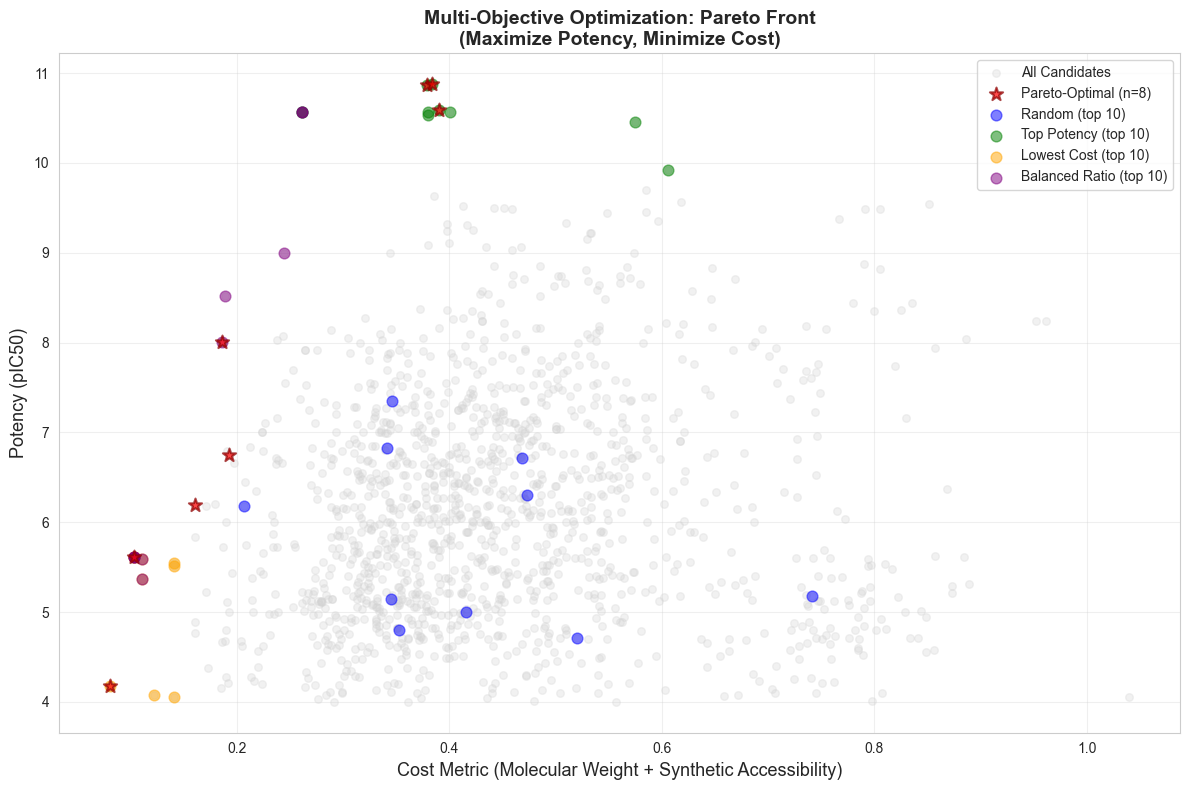

In [60]:
# Pareto Front Visualization
fig, ax = plt.subplots(figsize=(12, 8))

# Plot all candidates
ax.scatter(df_test['cost_metric'], df_test['pIC50'], 
           alpha=0.3, s=30, c='lightgray', label='All Candidates', zorder=1)

# Plot Pareto-optimal compounds
ax.scatter(pareto_compounds['cost_metric'], pareto_compounds['pIC50'],
           alpha=0.7, s=100, c='red', marker='*', 
           edgecolors='darkred', linewidths=1.5,
           label=f'Pareto-Optimal (n={len(pareto_compounds)})', zorder=3)

# Highlight top selections from different strategies
colors = {'Random': 'blue', 'Top Potency': 'green', 'Lowest Cost': 'orange', 'Balanced Ratio': 'purple'}
for strategy_name, color in colors.items():
    selected = baseline_strategies[strategy_name].head(10)
    ax.scatter(selected['cost_metric'], selected['pIC50'],
               alpha=0.5, s=60, c=color, marker='o',
               label=f'{strategy_name} (top 10)', zorder=2)

ax.set_xlabel('Cost Metric (Molecular Weight + Synthetic Accessibility)', fontsize=13)
ax.set_ylabel('Potency (pIC50)', fontsize=13)
ax.set_title('Multi-Objective Optimization: Pareto Front\n(Maximize Potency, Minimize Cost)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/pareto_front.png", dpi=300, bbox_inches='tight')
plt.show()

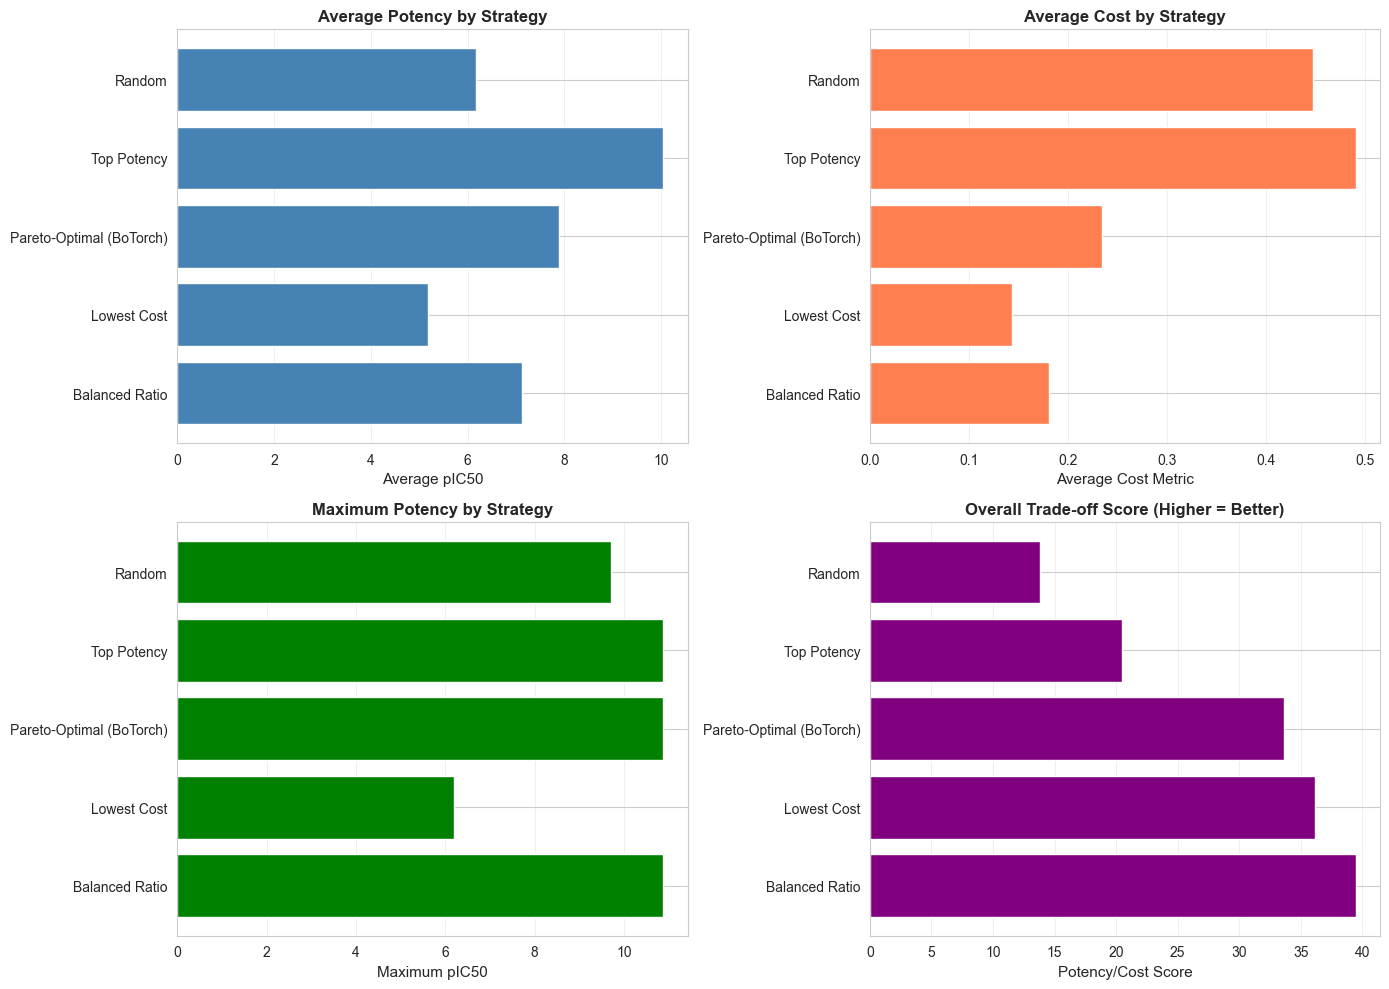

In [61]:
# Strategy comparison bar plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].barh(comparison_df['Strategy'], comparison_df['Avg_Potency'], color='steelblue')
axes[0, 0].set_xlabel('Average pIC50', fontsize=11)
axes[0, 0].set_title('Average Potency by Strategy', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

axes[0, 1].barh(comparison_df['Strategy'], comparison_df['Avg_Cost'], color='coral')
axes[0, 1].set_xlabel('Average Cost Metric', fontsize=11)
axes[0, 1].set_title('Average Cost by Strategy', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

axes[1, 0].barh(comparison_df['Strategy'], comparison_df['Max_Potency'], color='green')
axes[1, 0].set_xlabel('Maximum pIC50', fontsize=11)
axes[1, 0].set_title('Maximum Potency by Strategy', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

axes[1, 1].barh(comparison_df['Strategy'], comparison_df['Potency_Cost_Product'], color='purple')
axes[1, 1].set_xlabel('Potency/Cost Score', fontsize=11)
axes[1, 1].set_title('Overall Trade-off Score (Higher = Better)', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/strategy_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

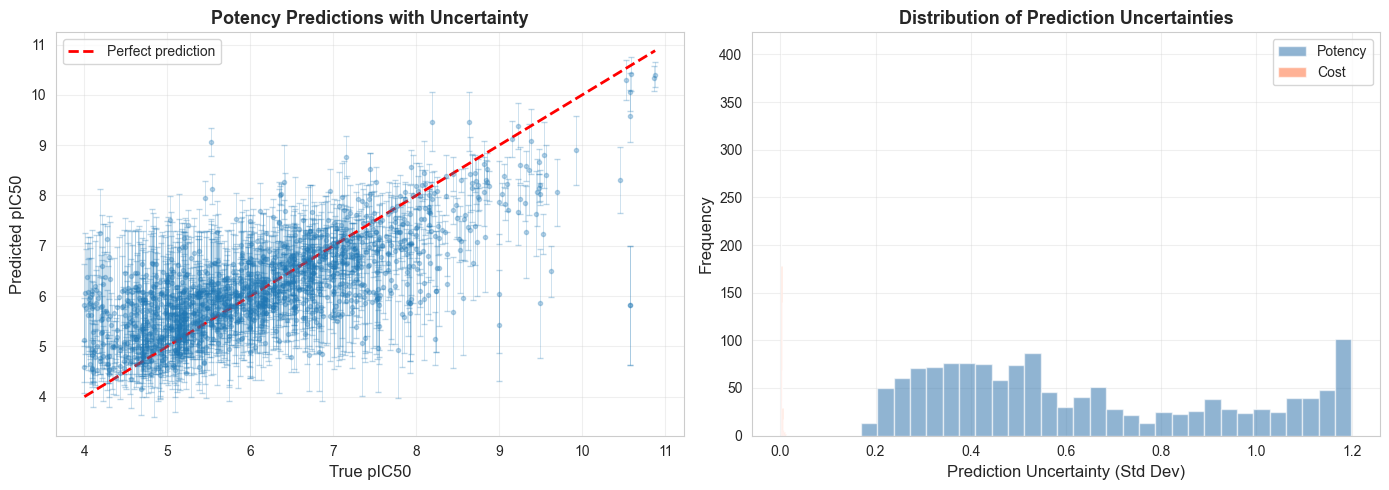

In [62]:
# Uncertainty visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].errorbar(y_test[:, 0], mean_potency.numpy(), 
                 yerr=std_potency.numpy(), 
                 fmt='o', alpha=0.3, markersize=3, elinewidth=0.5, capsize=2)
axes[0].plot([y_test[:, 0].min(), y_test[:, 0].max()], 
             [y_test[:, 0].min(), y_test[:, 0].max()], 
             'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('True pIC50', fontsize=12)
axes[0].set_ylabel('Predicted pIC50', fontsize=12)
axes[0].set_title('Potency Predictions with Uncertainty', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(std_potency.numpy(), bins=30, alpha=0.6, color='steelblue', label='Potency')
axes[1].hist(std_cost.numpy(), bins=30, alpha=0.6, color='coral', label='Cost')
axes[1].set_xlabel('Prediction Uncertainty (Std Dev)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Prediction Uncertainties', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/uncertainty_visualization.png", dpi=300, bbox_inches='tight')
plt.show()


Top 6 Pareto-Optimal Compounds (BoTorch Selection):


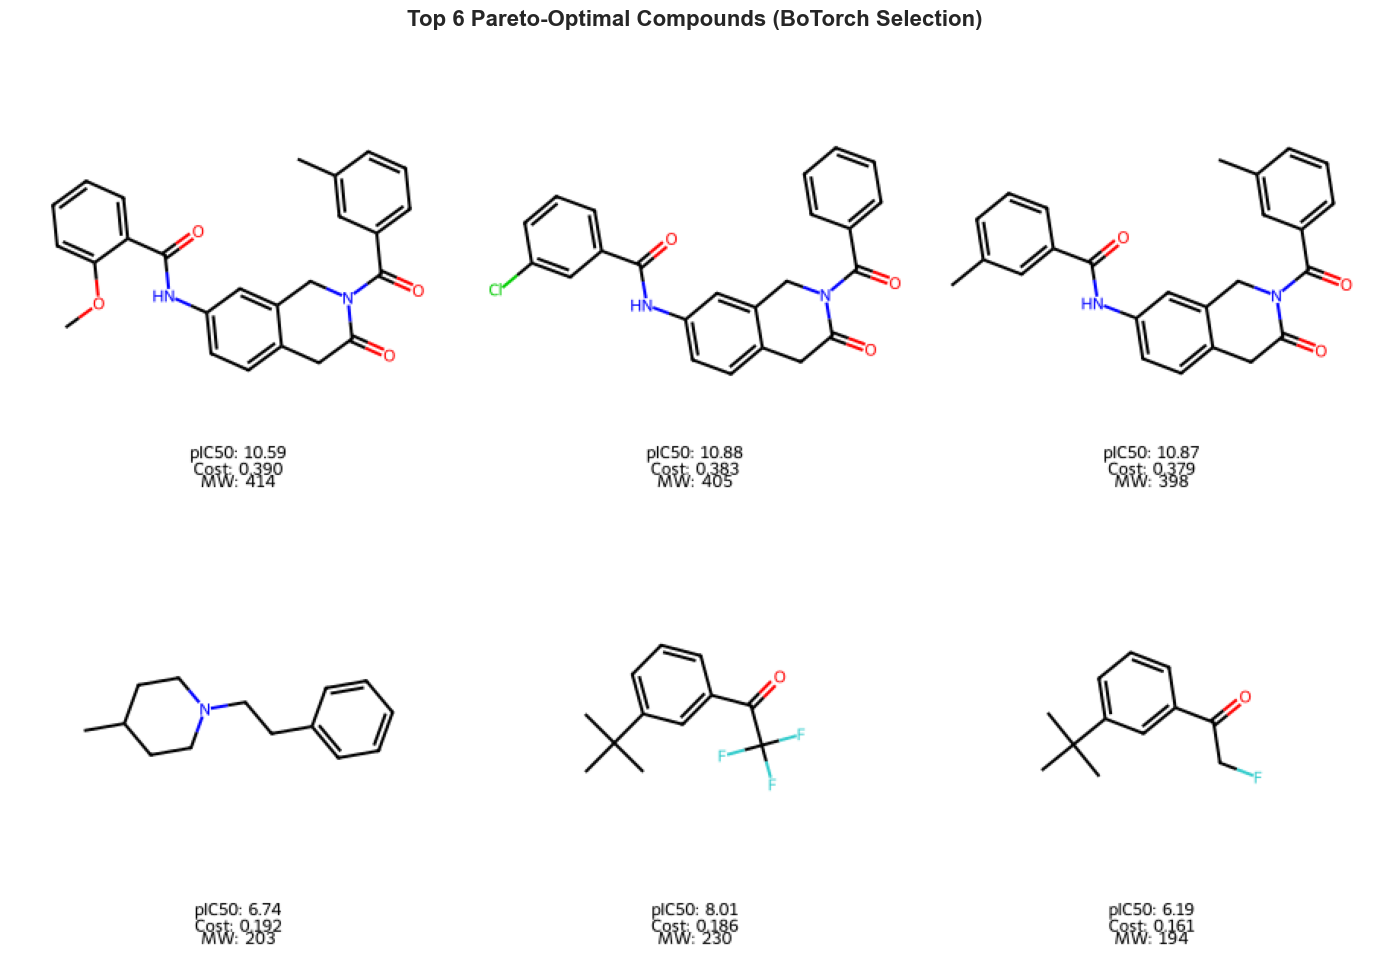

In [63]:
def visualize_top_compounds(df_selection, title="Top Compounds", n_display=6):
    top_compounds = df_selection.head(n_display)
    
    mols, legends = [], []
    for _, row in top_compounds.iterrows():
        mol = Chem.MolFromSmiles(row['canonical_smiles'])
        if mol is not None:
            mols.append(mol)
            legend = f"pIC50: {row['pIC50']:.2f}\nCost: {row['cost_metric']:.3f}\nMW: {row['mol_weight']:.0f}"
            legends.append(legend)
    
    if mols:
        img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300, 300),
                                   legends=legends, returnPNG=False)
        fig, ax = plt.subplots(figsize=(14, 10))
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No valid molecules to display for {title}")


# Visualize top Pareto-optimal compounds
print("\nTop 6 Pareto-Optimal Compounds (BoTorch Selection):")
visualize_top_compounds(
    pareto_compounds.nlargest(6, 'predicted_potency'),
    title="Top 6 Pareto-Optimal Compounds (BoTorch Selection)",
    n_display=6
)


Top 6 compounds from 'Balanced Ratio' strategy:


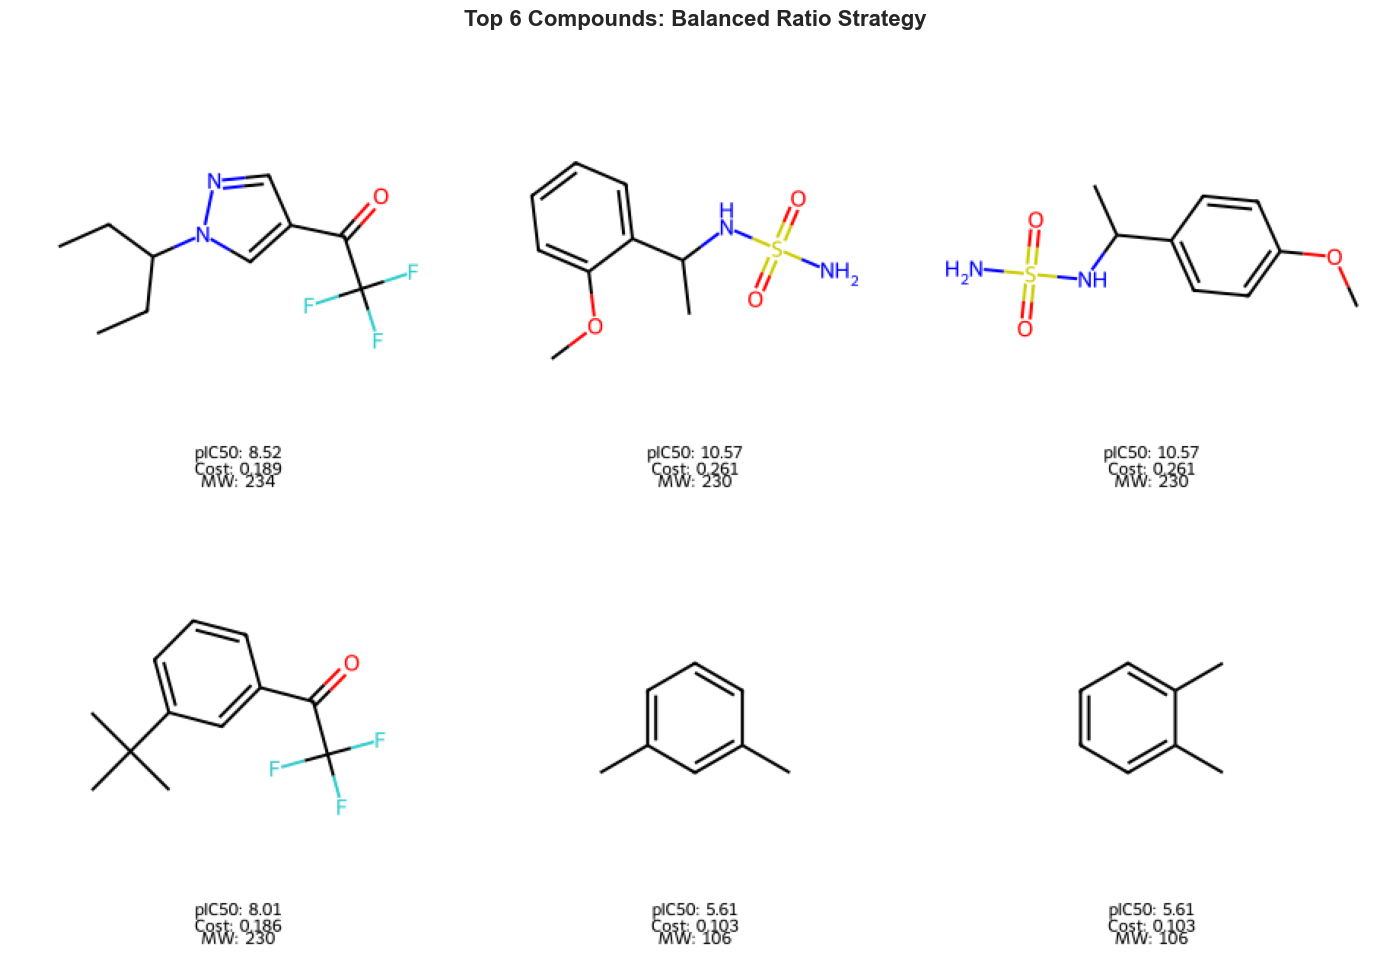

In [64]:
# Visualize compounds from other strategies
print("\nTop 6 compounds from 'Balanced Ratio' strategy:")
visualize_top_compounds(
    baseline_strategies['Balanced Ratio'],
    title="Top 6 Compounds: Balanced Ratio Strategy",
    n_display=6
)

---
## 11. Pareto-Optimal Compounds Analysis

In [65]:
print("PARETO-OPTIMAL COMPOUNDS ANALYSIS")

print(f"\nTotal Pareto-optimal compounds: {len(pareto_compounds)}")
print(f"\nDescriptor Statistics for Pareto-Optimal Compounds:")
display(pareto_compounds[CONFIG['feature_cols'] + ['pIC50', 'cost_metric']].describe())

print(f"\n\nComparison with Overall Dataset:")
print(f"{'Metric':<20} {'Overall Mean':<15} {'Pareto Mean':<15} {'Difference':<15}")

for col in ['pIC50', 'mol_weight', 'logp', 'sa_score', 'cost_metric']:
    overall_mean = df_test[col].mean()
    pareto_mean = pareto_compounds[col].mean()
    diff = pareto_mean - overall_mean
    print(f"{col:<20} {overall_mean:<15.3f} {pareto_mean:<15.3f} {diff:<+15.3f}")

PARETO-OPTIMAL COMPOUNDS ANALYSIS

Total Pareto-optimal compounds: 8

Descriptor Statistics for Pareto-Optimal Compounds:


,mol_weight,logp,hbd,hba,rotatable_bonds,tpsa,sa_score,rings,pIC50,cost_metric
count,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
mean,251.722375,2.950748,0.750000,1.875000,2.000000,41.923750,2.172792,2.125000,7.882289,0.234501
std,138.786395,1.616810,0.707107,1.246423,1.511858,28.760361,1.228551,1.642081,2.627095,0.129625
min,61.040000,-0.376900,0.000000,1.000000,0.000000,3.240000,1.000000,0.000000,4.173925,0.080520
25%,172.475750,2.615055,0.000000,1.000000,0.750000,17.070000,1.207747,1.000000,6.043980,0.146625
50%,216.779000,3.432700,1.000000,1.000000,2.500000,44.670000,1.617116,1.500000,7.376751,0.189245
75%,400.059750,4.055975,1.000000,3.000000,3.000000,66.480000,3.600239,4.000000,10.657030,0.380042
max,414.461000,4.317400,2.000000,4.000000,4.000000,75.710000,3.657844,4.000000,10.878440,0.390123




Comparison with Overall Dataset:
Metric               Overall Mean    Pareto Mean     Difference     
pIC50                6.150           7.882           +1.733         
mol_weight           426.961         251.722         -175.239       
logp                 4.210           2.951           -1.259         
sa_score             4.620           2.173           -2.447         
cost_metric          0.444           0.235           -0.210         


---
## 12. Export Results

In [66]:
print("EXPORTING RESULTS")

# Export Pareto-optimal compounds
pareto_export = pareto_compounds[[
    'canonical_smiles', 'pIC50', 'cost_metric', 'mol_weight', 
    'logp', 'sa_score', 'predicted_potency', 'predicted_neg_cost'
]].copy()
pareto_export.to_csv(f"{CONFIG['output_dir']}/pareto_optimal_compounds.csv", index=False)
print(f" Saved Pareto-optimal compounds to: {CONFIG['output_dir']}/pareto_optimal_compounds.csv")

# Export strategy comparison
comparison_df.to_csv(f"{CONFIG['output_dir']}/strategy_comparison.csv", index=False)
print(f" Saved strategy comparison to: {CONFIG['output_dir']}/strategy_comparison.csv")

# Export all baseline selections
for strategy_name, selected_df in baseline_strategies.items():
    filename = f"selected_compounds_{strategy_name.replace(' ', '_').replace('-', '_').lower()}.csv"
    cols = ['canonical_smiles', 'pIC50', 'cost_metric', 'mol_weight', 'sa_score']
    available_cols = [c for c in cols if c in selected_df.columns]
    selected_df[available_cols].to_csv(f"{CONFIG['output_dir']}/{filename}", index=False)
    print(f" Saved {strategy_name} selections to: {CONFIG['output_dir']}/{filename}")

print("ALL RESULTS EXPORTED SUCCESSFULLY!")


EXPORTING RESULTS
 Saved Pareto-optimal compounds to: results/pareto_optimal_compounds.csv
 Saved strategy comparison to: results/strategy_comparison.csv
 Saved Random selections to: results/selected_compounds_random.csv
 Saved Top Potency selections to: results/selected_compounds_top_potency.csv
 Saved Lowest Cost selections to: results/selected_compounds_lowest_cost.csv
 Saved Balanced Ratio selections to: results/selected_compounds_balanced_ratio.csv
 Saved Pareto-Optimal (BoTorch) selections to: results/selected_compounds_pareto_optimal_(botorch).csv
ALL RESULTS EXPORTED SUCCESSFULLY!


---
## 13. Summary

In [67]:
print("MULTI-OBJECTIVE BAYESIAN OPTIMIZATION SUMMARY")

print(f"\n Dataset Information:")
print(f"   - Total compounds analyzed: {len(df)}")
print(f"   - Training set: {len(X_train)} compounds")
print(f"   - Candidate pool: {len(X_test)} compounds")
print(f"   - Pareto-optimal compounds found: {len(pareto_compounds)}")

print(f"\n Optimization Objectives:")
print(f"   1. Maximize Potency (pIC50)")
print(f"   2. Minimize Cost (Molecular Weight + Synthetic Accessibility)")

print(f"\n Model Performance:")
print(f"   - Potency prediction R²: {potency_r2:.4f}")
print(f"   - Cost prediction R²: {cost_r2:.4f}")

print(f"\n Best Strategy: {comparison_df.iloc[0]['Strategy']}")
print(f"   - Average Potency: {comparison_df.iloc[0]['Avg_Potency']:.3f}")
print(f"   - Average Cost: {comparison_df.iloc[0]['Avg_Cost']:.3f}")
print(f"   - Trade-off Score: {comparison_df.iloc[0]['Potency_Cost_Product']:.3f}")

print(f"\n Key Insights:")
print(f"   - Pareto-optimal compounds represent {100*len(pareto_compounds)/len(X_test):.1f}% of candidates")
print(f"   - BoTorch multi-objective optimization identifies compounds with:")
print(f"     • {((pareto_compounds['pIC50'].mean() / df_test['pIC50'].mean() - 1) * 100):+.1f}% potency vs. average")
print(f"     • {((pareto_compounds['cost_metric'].mean() / df_test['cost_metric'].mean() - 1) * 100):+.1f}% cost vs. average")

print(f"\n Exported Files:")
print(f"   - {CONFIG['output_dir']}/pareto_optimal_compounds.csv")
print(f"   - {CONFIG['output_dir']}/strategy_comparison.csv")
print(f"   - {CONFIG['output_dir']}/selected_compounds_*.csv (for each strategy)")
print(f"   - {CONFIG['output_dir']}/*.png (visualizations)")



MULTI-OBJECTIVE BAYESIAN OPTIMIZATION SUMMARY

 Dataset Information:
   - Total compounds analyzed: 4624
   - Training set: 3236 compounds
   - Candidate pool: 1388 compounds
   - Pareto-optimal compounds found: 8

 Optimization Objectives:
   1. Maximize Potency (pIC50)
   2. Minimize Cost (Molecular Weight + Synthetic Accessibility)

 Model Performance:
   - Potency prediction R²: 0.5263
   - Cost prediction R²: 1.0000

 Best Strategy: Balanced Ratio
   - Average Potency: 7.129
   - Average Cost: 0.181
   - Trade-off Score: 39.468

 Key Insights:
   - Pareto-optimal compounds represent 0.6% of candidates
   - BoTorch multi-objective optimization identifies compounds with:
     • +28.2% potency vs. average
     • -47.2% cost vs. average

 Exported Files:
   - results/pareto_optimal_compounds.csv
   - results/strategy_comparison.csv
   - results/selected_compounds_*.csv (for each strategy)
   - results/*.png (visualizations)
